# X-Means Clustering

In this notebook, we apply the **X-Means** clustering algorithm using the **pyclustering** library.  

X-Means is employed as an alternative clustering approach to automatically infer the optimal number of clusters, addressing one of the main limitations of traditional K-Means.

The clustering is performed on the final cleaned and engineered dataset obtained in the previous notebooks.

---

## X-Means Algorithm Overview

X-Means is an extension of the K-Means algorithm designed to automatically determine the appropriate number of clusters within a given range. Instead of fixing the number of clusters _a priori_, X-Means starts from an initial value of $k$ and iteratively attempts to split existing clusters.

At each iteration, candidate splits are evaluated using a statistical criterion, in this case the **Bayesian Information Criterion (BIC)**, to assess whether the split improves the overall model. If the split is accepted, the cluster is divided; otherwise, it is retained as is.

This approach allows X-Means to adapt the model complexity to the structure of the data, making it particularly suitable for exploratory and unsupervised tasks such as distinguishing different styles of Italian rap.

In [45]:
import pandas as pd
import numpy as np
from pyclustering.cluster.xmeans import xmeans
from pyclustering.utils import timedcall
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns
from sklearn.manifold import TSNE

---

## Reproducibility and Data Preparation

To ensure reproducibility of the clustering results, we fix the random seed used throughout the analysis.

Before applying the X-Means algorithm, the data undergoes the following preparation steps:
- standardization using _StandardScaler_, in order to ensure that all features contribute equally to the distance computation;
- conversion of the dataset into a list-based format, as required by the **pyclustering** library.

In [46]:

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [47]:
"""
    Loading the dataset
"""
df = pd.read_csv("../clustering_dataset/merged_dataset_clean.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: 5016 rows x 12 columns
Columns: ['avg_token_per_clause', 'duration_ms', 'popularity', 'swear_ratio', 'syntactic_complexity', 'flow_complexity', 'percussiveness', 'harmonic_richness', 'trap_index', 'boombap_index', 'cloud_rap_index', 'drill_index']


In [48]:

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

data_list = data_scaled.tolist()

---

## Manual Initialization of Cluster Centers

While initializing cluster centers using `kmeans_plusplus_initializer` from **pyclustering**, an error occurs due to a compatibility issue with NumPy.

We override this problem by manually initializing the cluster centers, simulating the behavior of **k-means++** by selecting points that are well separated.

In [49]:

np.random.seed(RANDOM_SEED)

# Smart initialization: first center chosen randomly
n_initial_centers = 2
first_idx = np.random.randint(len(data_list))
initial_centers = [data_list[first_idx]]
selected_indices = [first_idx]

# Other centers chosen by max distance fro existing centers
for _ in range(n_initial_centers - 1):
    # Calculating min distance from each point to the existing centers
    min_distances = []
    for i, point in enumerate(data_list):
        if i not in selected_indices:
            distances = [np.linalg.norm(np.array(point) - np.array(c)) for c in initial_centers]
            min_distances.append((i, min(distances)))
    
    # Chooses the furthest center
    next_idx = max(min_distances, key=lambda x: x[1])[0]
    initial_centers.append(data_list[next_idx])
    selected_indices.append(next_idx)

print(f"Initial selected centers: indexes {selected_indices}")

Initial selected centers: indexes [860, 3514]


---

## Executing X-Means Clustering

At this stage, we execute the X-Means clustering algorithm on the prepared dataset. The algorithm is allowed to explore different cluster configurations up to a predefined maximum number of clusters, specified by the `kmax` parameter.

Once the clustering process is complete, we retrieve the main results, including the final number of clusters identified by the algorithm and the number of data points assigned to each cluster.

Finally, the cluster labels are added to the original dataframe, enabling further analysis and interpretation of the clustering results.

In [50]:
xmeans_instance = xmeans(
    data_list, 
    initial_centers, 
    kmax=10,
    tolerance=0.001
)

# Timing the execution
(ticks, _) = timedcall(xmeans_instance.process)
print(f"Execution time: {ticks:.2f} seconds")

# Results
clusters = xmeans_instance.get_clusters()
centers = xmeans_instance.get_centers()

print(f"Number of clusters: {len(clusters)}")

print(f"Points distribution per cluster:")
for i, cluster in enumerate(clusters):
    percentage = (len(cluster) / len(data_list)) * 100
    print(f"  Cluster {i}: {len(cluster):4d} points ({percentage:5.2f}%)")

# Adding clusters labels to the original dataframe
labels = np.zeros(len(data_scaled), dtype=int)
for cluster_idx, cluster_points in enumerate(clusters):
    for point_idx in cluster_points:
        labels[point_idx] = cluster_idx

df['cluster'] = labels

Execution time: 0.62 seconds
Number of clusters: 3
Points distribution per cluster:
  Cluster 0: 1762 points (35.13%)
  Cluster 1: 1666 points (33.21%)
  Cluster 2: 1588 points (31.66%)


---

## Cluster Evaluation

To assess the quality of the clustering results, we compute two widely used internal validation metrics: the **Silhouette Index** and the **Davies–Bouldin Score**. These measures provide complementary insights into cluster compactness and separation.

In addition to quantitative evaluation, we analyze the distribution of data points across clusters. Specifically, we visualize the number of points assigned to each cluster using a bar chart, which helps identify potential imbalance among clusters.

Finally, we compute and plot the cumulative percentage of data points, sorted by cluster size. This analysis highlights how much of the dataset is explained by the largest clusters and provides further insight into the overall clustering structure.

In [51]:
def clusters_distribution():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Graph 1: clusters dimension
    cluster_sizes = [len(c) for c in clusters]
    bars = ax1.bar(range(len(clusters)), cluster_sizes, color="cornflowerblue", edgecolor='black')
    ax1.set_xlabel("Cluster ID")
    ax1.set_ylabel("Number of points")
    ax1.set_title("Clusters dimension distribution")
    ax1.grid(True, alpha=0.3, axis="y")

    for i, (bar, size) in enumerate(zip(bars, cluster_sizes)):
        percentage = (size / len(data_list)) * 100
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cluster_sizes) * 0.01, 
                f'{percentage:.1f}%', ha='center', va='bottom', fontsize=8)

    # Graph 2: cumulative percentage
    sorted_sizes = sorted(cluster_sizes, reverse=True)
    cumulative = np.cumsum(sorted_sizes) / sum(cluster_sizes) * 100
    ax2.plot(range(1, len(clusters)+1), cumulative, marker='o', linewidth=2, markersize=8)
    ax2.axhline(y=80, color='r', linestyle='--', label='80%')
    ax2.set_xlabel("Number of dimension ordinated cluster")
    ax2.set_ylabel("Cumulative percentage")
    ax2.set_title("Cumulative span of clusters")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return

Silhouette Score: 0.1091
    RANGE: [-1, 1], BEST: 1)
Davies-Bouldin Index: 2.3643
    RANGE: [0, +inf), BEST: 0


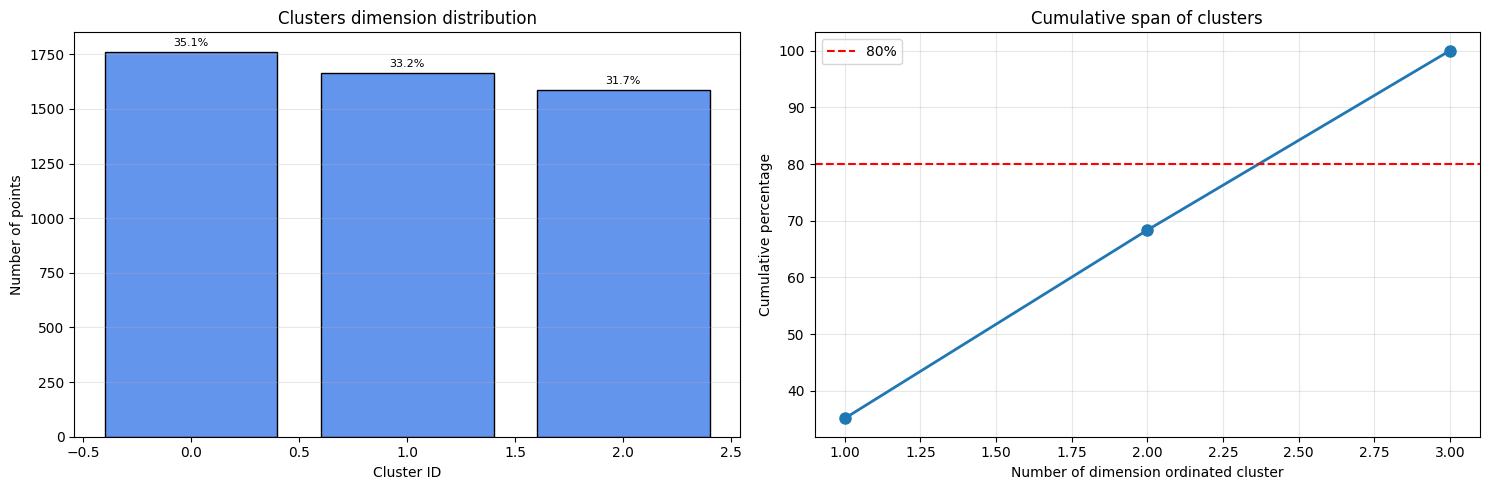

In [52]:
# Silhouette score
silhouette = silhouette_score(data_scaled, labels)
print(f"Silhouette Score: {silhouette:.4f}\n    RANGE: [-1, 1], BEST: 1)")

# Davies-Bouldin score
davies_bouldin = davies_bouldin_score(data_scaled, labels)

print(f"Davies-Bouldin Index: {davies_bouldin:.4f}\n    RANGE: [0, +inf), BEST: 0")

clusters_distribution()

---

## Cluster Visualization

To gain an intuitive understanding of the clustering structure, we visualize the clusters using dimensionality reduction techniques. In particular, we project the high-dimensional data into a two-dimensional space using **PCA**, **UMAP**, and **t-SNE**.

These methods allow us to visually assess the separation and compactness of the clusters, offering complementary perspectives on the underlying data structure. While PCA provides a linear projection that preserves global variance, UMAP and t-SNE focus on capturing non-linear relationships and local neighborhood structures.

In [53]:
def PCA_visualization():
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    data_2d = pca.fit_transform(data_scaled)
    centers_array = np.array(centers)
    centers_2d = pca.transform(centers_array)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, 
                         cmap="viridis", alpha=0.6, s=30)
    plt.scatter(centers_2d[:, 0], centers_2d[:, 1], 
               c="red", marker="X", s=200, edgecolors="black", 
               linewidths=2, label="Centroids")
    plt.colorbar(scatter, label="Cluster")
    plt.xlabel(f"First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.title(f"X-means Clustering - {len(clusters)} clusters found")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

def UMAP_visualization():
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        random_state=RANDOM_SEED,
        n_jobs=1,
        low_memory=True,
        verbose=False
    )
    
    data_2d_umap = reducer.fit_transform(data_scaled)

    centers_array = np.array(centers)
    centers_2d_umap = reducer.transform(centers_array)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(data_2d_umap[:, 0], data_2d_umap[:, 1], c=labels, 
                         cmap='viridis', alpha=0.6, s=30)
    plt.scatter(centers_2d_umap[:, 0], centers_2d_umap[:, 1], 
               c='red', marker='X', s=200, edgecolors='black', 
               linewidths=2, label="Centroids")
    plt.colorbar(scatter, label="Clusters")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"UMAP - {len(clusters)} clusters")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

def tSNE_visualization():
    # Combining data and centers to project them onto the same space
    centers_array = np.array(centers)
    combined_data = np.vstack([data_scaled, centers_array])

    tsne = TSNE(
    n_components=2,
    perplexity=10,
    early_exaggeration=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_SEED
    )

    combined_2d = tsne.fit_transform(combined_data)

    # Separating data again
    data_2d_tsne = combined_2d[:len(data_scaled)]
    centers_2d_tsne = combined_2d[len(data_scaled):]

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        data_2d_tsne[:, 0],
        data_2d_tsne[:, 1],
        c=labels,
        cmap='viridis',
        alpha=0.6,
        s=30
    )

    plt.scatter(
        centers_2d_tsne[:, 0],
        centers_2d_tsne[:, 1],
        c='red',
        marker='X',
        s=250,
        edgecolors='black',
        linewidths=2,
        label='Centroids'
    )

    plt.colorbar(scatter, label="Cluster")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(f"t-SNE Visualization - {len(clusters)} clusters")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

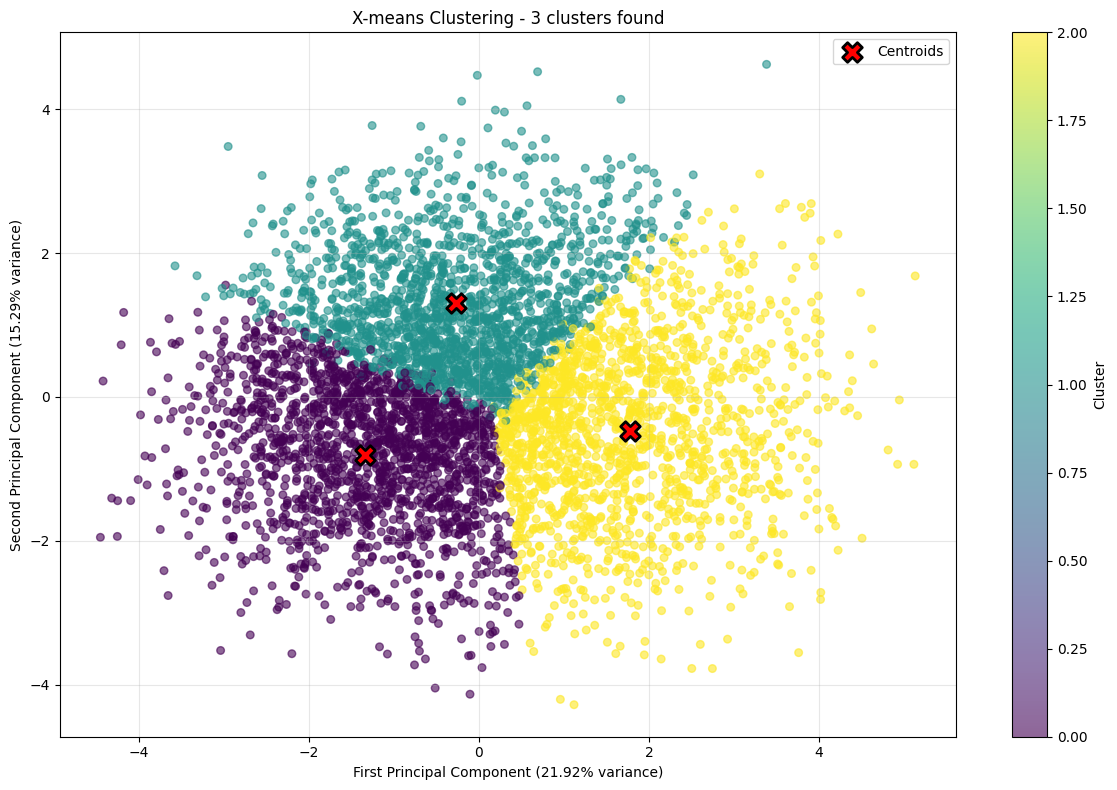

In [54]:
PCA_visualization()

/home/matilde/Documents/data_mining_unipi/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/matilde/Documents/data_mining_unipi/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


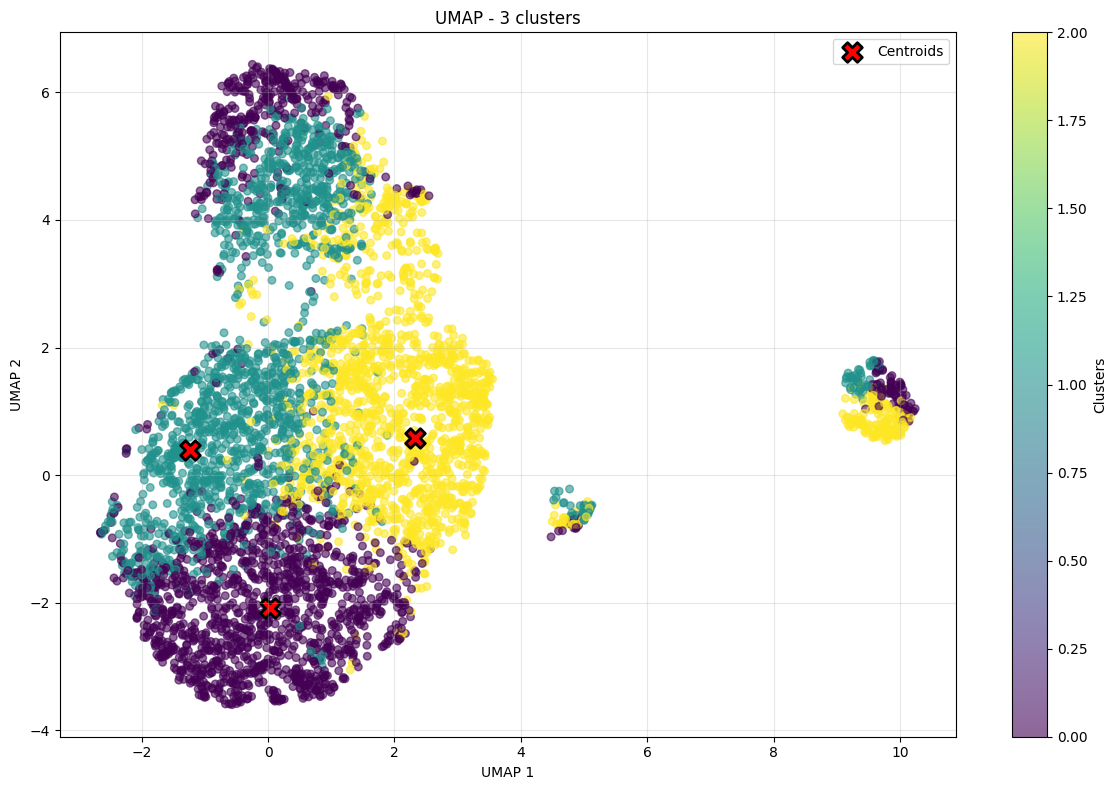

In [55]:
UMAP_visualization()

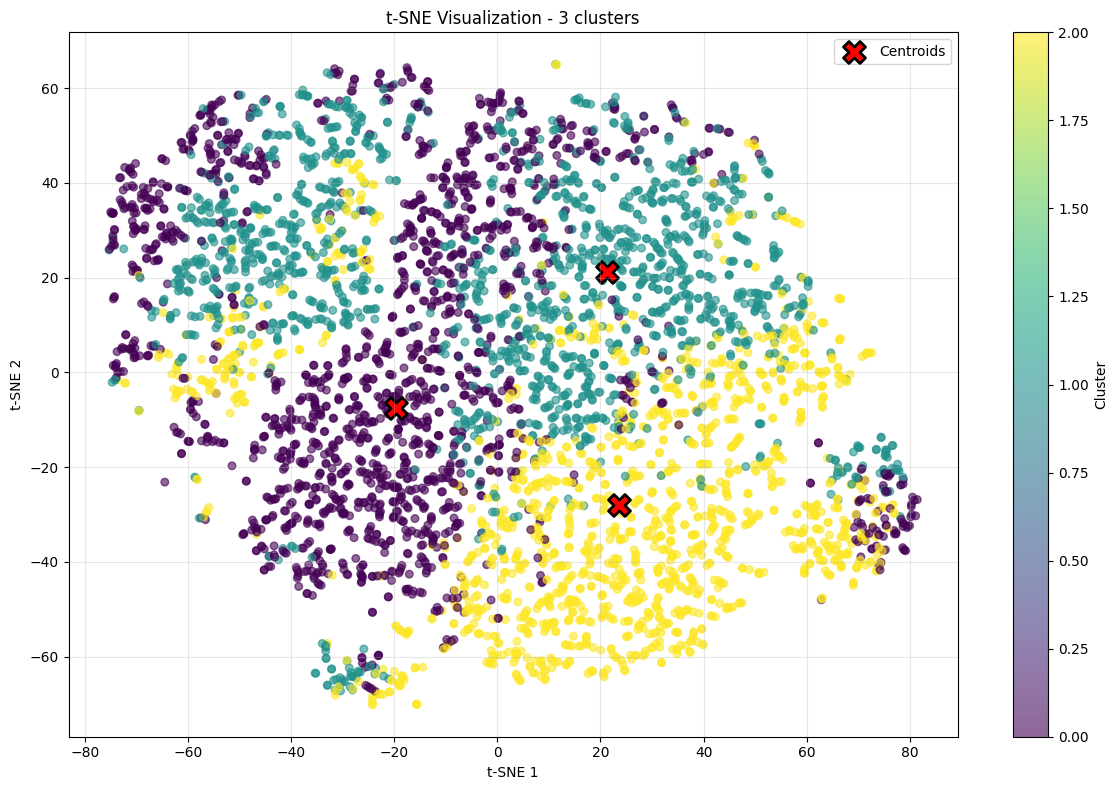

In [56]:
tSNE_visualization()

---

## Cluster Characterization

To gain a deeper understanding of the identified clusters, we perform a detailed cluster characterization based on descriptive statistics and visual analysis.

In [57]:
def cluster_heatmaps():
    # Features mean per cluster
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Remove cluster column
    numeric_cols = [col for col in numeric_cols if col not in ["cluster"]]

    cluster_means = df.groupby("cluster")[numeric_cols].mean()

    # Normalization per row (z-score) to see intra-cluster differences
    cluster_means_normalized = (
        cluster_means
        .sub(cluster_means.mean(axis=1), axis=0)
        .div(cluster_means.std(axis=1), axis=0)
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, max(8, len(clusters) * 0.8)))

    # Heatmap 1: Absolute Values
    sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="RdYlGn", 
                center=cluster_means.mean().mean(), ax=ax1, 
                cbar_kws={"label": "Mean Value"})
    ax1.set_title("Cluster characterization - Mean Values per Feature")
    ax1.set_xlabel("Features")
    ax1.set_ylabel("Cluster ID")

    # Heatmap 2: Z-score
    sns.heatmap(cluster_means_normalized, annot=True, fmt=".2f", cmap="coolwarm", 
                center=0, ax=ax2, vmin=-2, vmax=2,
                cbar_kws={"label": "Z-score (standard deviations from mean)"})
    ax2.set_title("Cluster characterization - Relative Deviations (Z-score)")
    ax2.set_xlabel("Features")
    ax2.set_ylabel("Cluster ID")

    plt.tight_layout()
    plt.show()
    return

def boxplot_zscore_features():
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ["cluster"]]
    df_z = df.copy()
    df_z[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])

    df_long_z = df_z.melt(
        id_vars="cluster",
        value_vars=numeric_cols,
        var_name="feature",
        value_name="z_value"
    )

    g = sns.catplot(
        data=df_long_z,
        x="cluster",
        y="z_value",
        col="feature",
        col_wrap=4,
        kind="box",
        sharey=True,
        height=4,
        aspect=1,
        palette="Set2"
    )

    g.fig.subplots_adjust(top=0.92)
    g.fig.suptitle("Features Distribution per Cluster (Z-score)", fontsize=16)

    for ax in g.axes.flatten():
        ax.axhline(0, color="red", linestyle="--", alpha=0.5)
        ax.grid(True, axis="y", alpha=0.3)

    plt.show()
    return


### Descriptive Statistics

We first compute descriptive statistics for each cluster by grouping the dataset according to the assigned cluster label and calculating the **mean** and **standard deviation** of each feature.

This provides an initial quantitative summary of how feature values differ across clusters and how much variability is present within each cluster.

In [58]:
print(f"Descriptive statistics for the clusters:")
cluster_stats = df.groupby('cluster').agg(['mean', 'std'])
print(cluster_stats)

Descriptive statistics for the clusters:
        avg_token_per_clause              duration_ms                \
                        mean       std           mean           std   
cluster                                                               
0                   6.179578  1.212383  195195.410897  37556.859588   
1                   7.465131  1.473893  200448.229892  39909.849527   
2                   6.916691  1.425776  195417.586902  39240.118849   

        popularity            swear_ratio           syntactic_complexity  \
              mean        std        mean       std                 mean   
cluster                                                                    
0        31.225880  19.175304    0.002140  0.003397           793.915891   
1        39.150060  18.410835    0.005935  0.004999          1226.994035   
2        31.846977  19.433693    0.004987  0.005026          1060.899260   

                     ... harmonic_richness               trap_index  \
    

### Feature Heatmaps

We then visualize cluster-level feature patterns using two complementary heatmaps.

The first heatmap displays the **absolute mean values** of each feature for every cluster. This representation highlights the overall magnitude of each feature and allows direct comparison across clusters, although it may still be influenced by differences in feature scale.

To emphasize **relative intra-cluster feature importance**, we construct a second heatmap based on **row-wise z-score normalization**.  
In this case, for each cluster, feature means are standardized by subtracting the cluster-specific mean and dividing by the cluster-specific standard deviation. As a result:
- positive z-score values indicate features that are relatively higher than the average feature value within the same cluster;
- negative z-score values indicate features that are relatively lower;
- values close to zero correspond to features that are close to the cluster’s internal average.

This normalized view is particularly useful for identifying which features characterize each cluster most strongly, independently of their original scale.

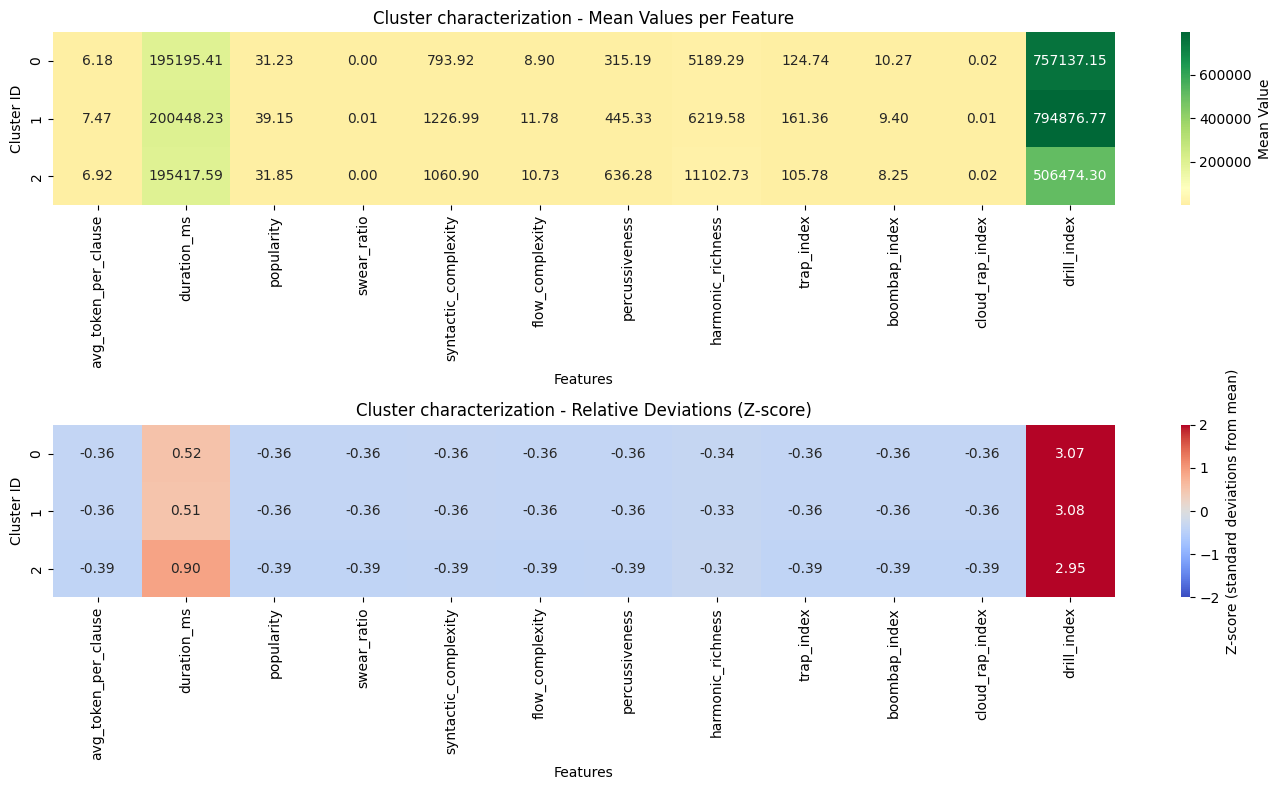

In [59]:
cluster_heatmaps()

### Boxplots on Z-Score Standardized Features

Finally, we analyze feature distributions within each cluster using boxplots computed on **z-score standardized data**.  
All numerical features are standardized across the entire dataset before plotting, ensuring comparability across features with different units and ranges.

In these boxplots:
- a median close to zero indicates that the feature is near the global dataset average for that cluster;
- positive (negative) values indicate that the feature tends to be higher (lower) than average;
- the spread of the box reflects intra-cluster variability;
- potential outliers highlight atypical observations within the cluster.

Together, these visualizations provide a comprehensive and interpretable characterization of each cluster, supporting the qualitative interpretation of the clustering results in terms of distinct rap styles.

/tmp/ipykernel_266138/3249923330.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


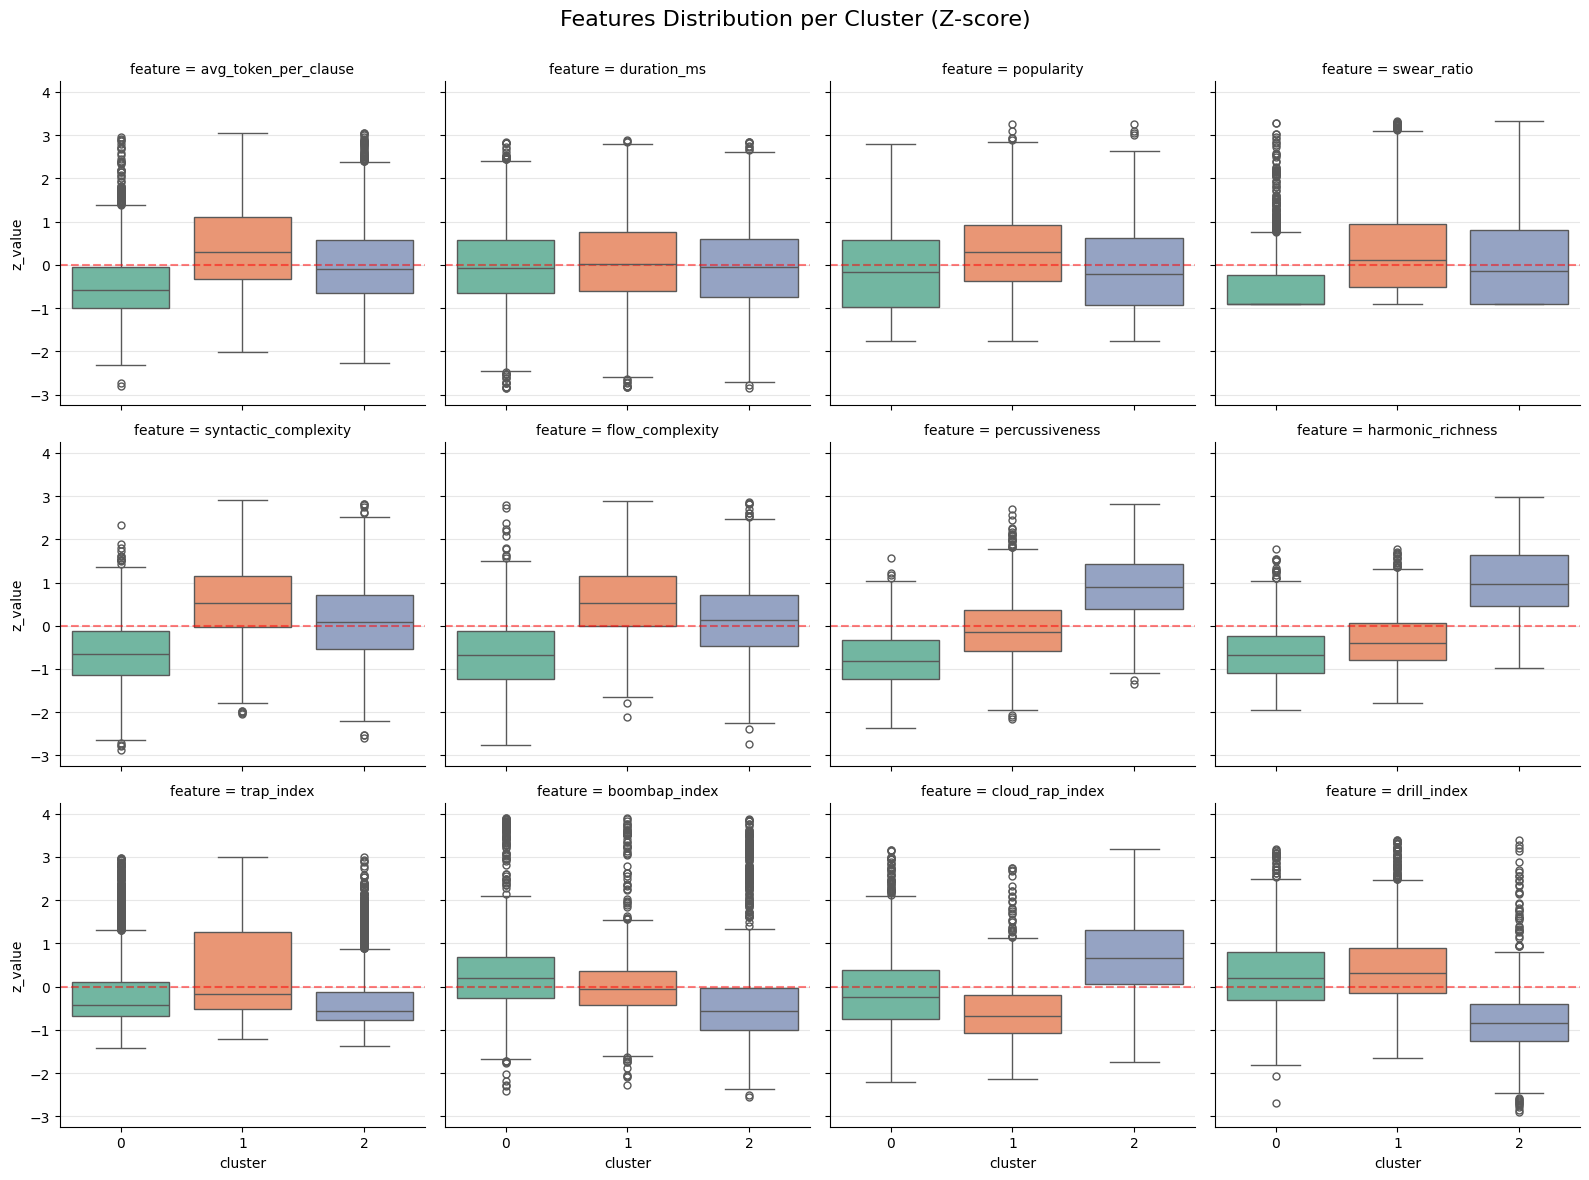

In [60]:
boxplot_zscore_features()